Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
#import LinearReg

Linear Regression

In [ ]:
import numpy as np

class Linear_Regression():

    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, X, Y):
        self.m, self.n = X.shape  # m = rows (samples), n = columns (features)

        # initializing weight and bias
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        # gradient descent
        for i in range(self.no_of_iterations):
            self.update_weight()

    def update_weight(self):
        Y_prediction = self.predict(self.X)

        # gradients
        dw = -(2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
        db = -(2 * np.sum(self.Y - Y_prediction)) / self.m

        # update
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def predict(self, X):
        return X.dot(self.w) + self.b



In [ ]:
df=pd.read_csv('/content/salary_data.csv')

In [ ]:
df.shape

(30, 2)

In [ ]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
# check for missing values
df.isnull().sum()


,0
YearsExperience,0
Salary,0


In [ ]:
x=df.iloc[:,:-1].values.reshape(-1,1)
y=df.iloc[:,1].values

In [ ]:
print(x)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [ ]:
print(y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


Split The Dataset For Training

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=2)

Training The Model

In [ ]:
model=Linear_Regression(0.02,1000)

In [ ]:
model.fit(x_train,y_train)

In [ ]:
# Final weight and bias values
print('weight=',model.w[0])
print('bias',model.b)

weight= 9514.400999035135
bias 23697.406507136307


Linear Regression Equation


Salary=9514(Years of Expe)+23697

Predict the value for test data



In [ ]:
test_data_pred=model.predict(x_test)

In [ ]:
print(test_data_pred)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


#Visualizing the predicted values and actual values


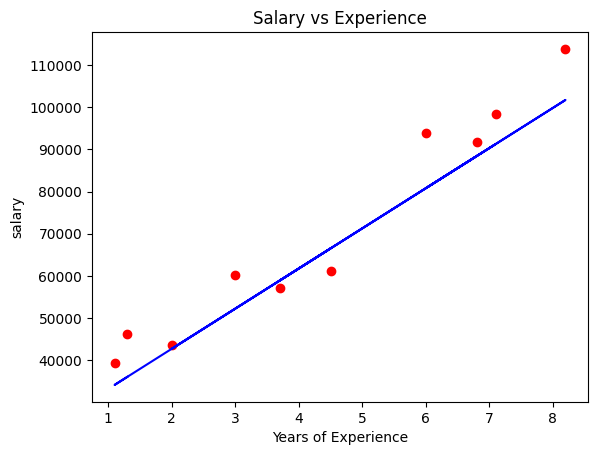

In [ ]:
plt.scatter(x_test,y_test,color='red')
plt.plot(x_test,test_data_pred,color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('salary')
plt.title('Salary vs Experience')
plt.show()